# Exploratory Data Analysis

This notebook performs a professional exploratory data analysis for the CDC Diabetes Health Indicators dataset. The goal is to assess the dataset structure, understand target balance, and analyze key relationships for a risk prediction workflow.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / 'src'))
from data_loader import load_cdc_diabetes_data

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 100})
OUTPUT_DIR = Path.cwd().parent / 'images'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Dataset overview

In [2]:
X, y, df = load_cdc_diabetes_data()

print('Full dataset shape:', df.shape)
print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

print('Columns:')
print(df.columns.tolist())

Full dataset shape: (253680, 22)
Feature matrix shape: (253680, 21)
Target vector shape: (253680,)
Columns:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


## Prediction task

The dataset is used to build a diabetes risk prediction study based on CDC health indicators and lifestyle variables. This analysis is intended to support data science model development, not medical diagnosis.

In [3]:
target_name = y.name if y.name else 'Diabetes_binary'

print('Target variable:', target_name)
print('\nTarget distribution:')
print(y.value_counts(dropna=False))
print('\nRelative frequency:')
print(y.value_counts(normalize=True).round(3))

Target variable: Diabetes_binary

Target distribution:
0    218334
1     35346
Name: Diabetes_binary, dtype: int64

Relative frequency:
0    0.861
1    0.139
Name: Diabetes_binary, dtype: float64


## Missing values and summary statistics

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values by column:')
print(missing[missing > 0])

print('Descriptive statistics for numeric columns:')
display(df.describe(include='number'))

Missing values by column:
Series([], dtype: int64)
Descriptive statistics for numeric columns:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


## Class imbalance analysis

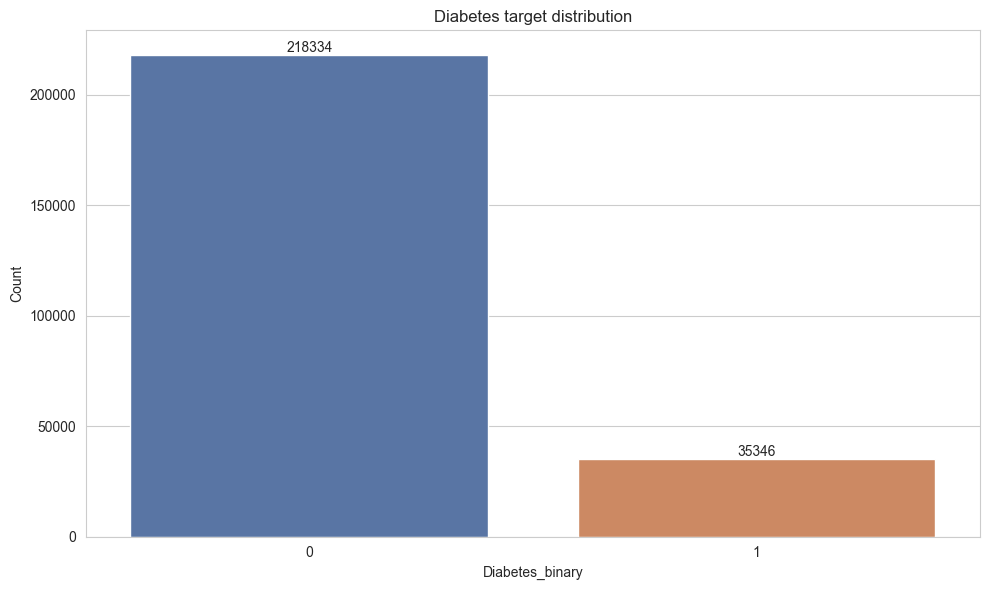

Saved plot to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/target_distribution.png


In [5]:
plt.figure()
ax = sns.countplot(x=y, hue=y, palette='deep', legend=False)
ax.set_title('Diabetes target distribution')
ax.set_xlabel(target_name)
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plot_path = OUTPUT_DIR / 'target_distribution.png'
plt.tight_layout()
plt.savefig(plot_path)
plt.show()
print(f'Saved plot to {plot_path}')

The target distribution chart identifies whether the dataset is balanced or requires special handling during model development.

## Distribution of key variables

Plotted columns: ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity', 'GenHlth', 'Income', 'Education']


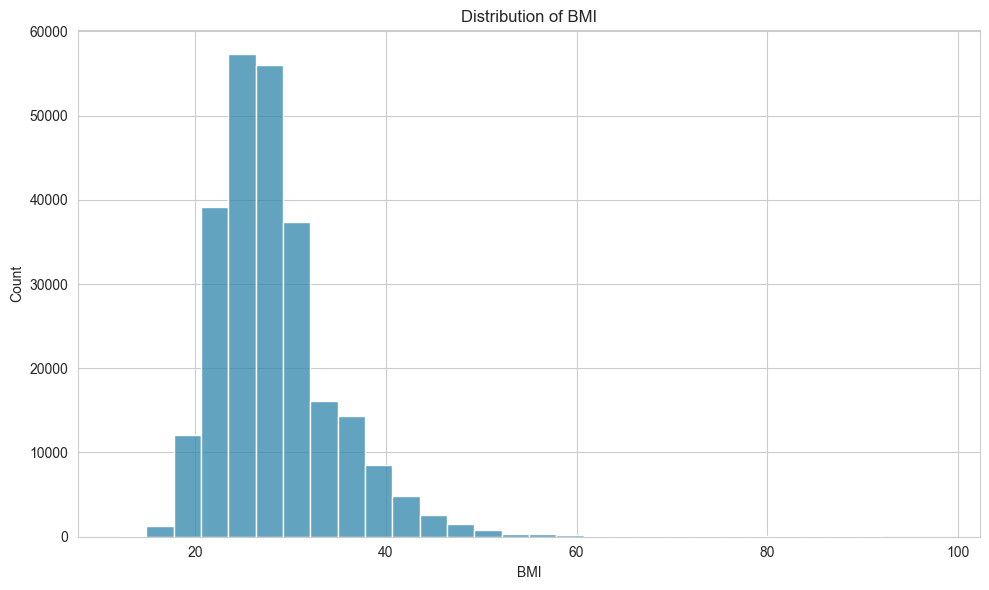

Saved plot for BMI to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_BMI.png


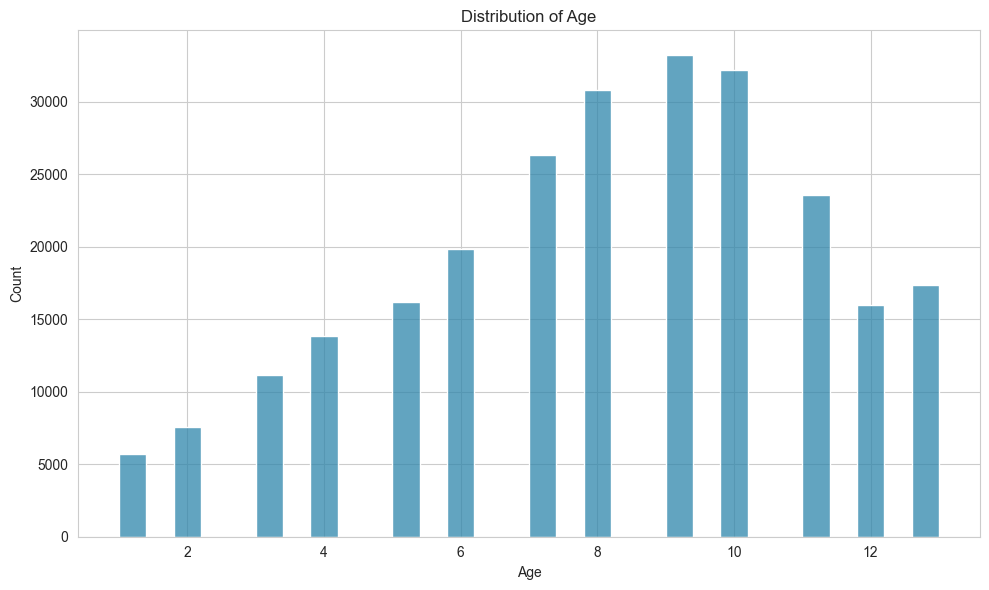

Saved plot for Age to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_Age.png


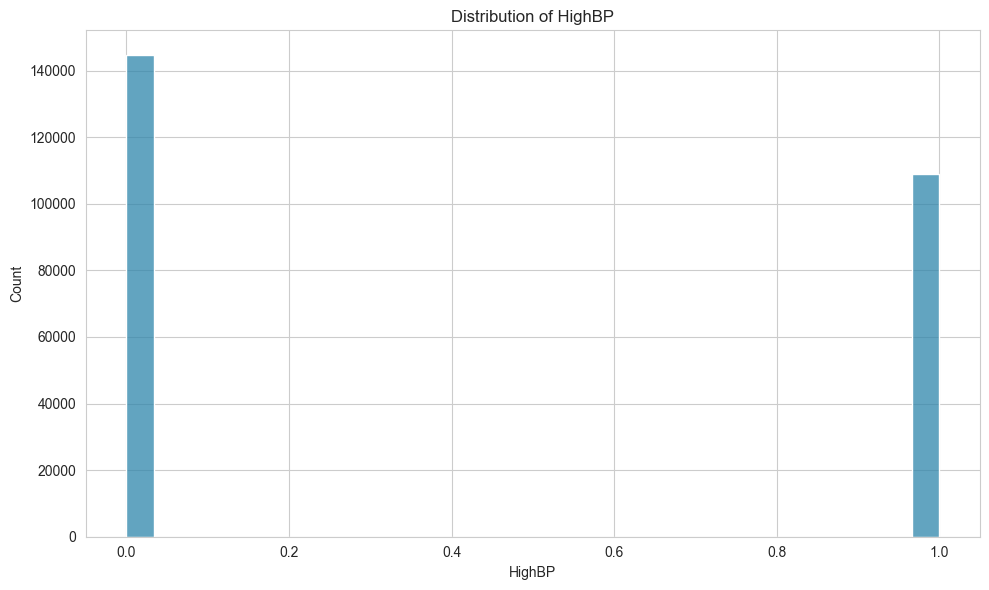

Saved plot for HighBP to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_HighBP.png


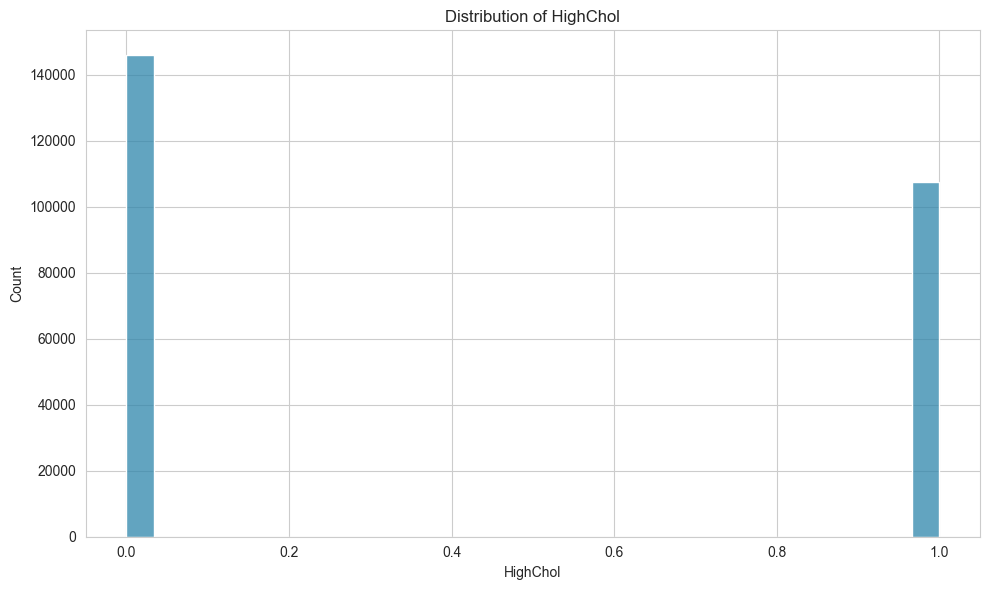

Saved plot for HighChol to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_HighChol.png


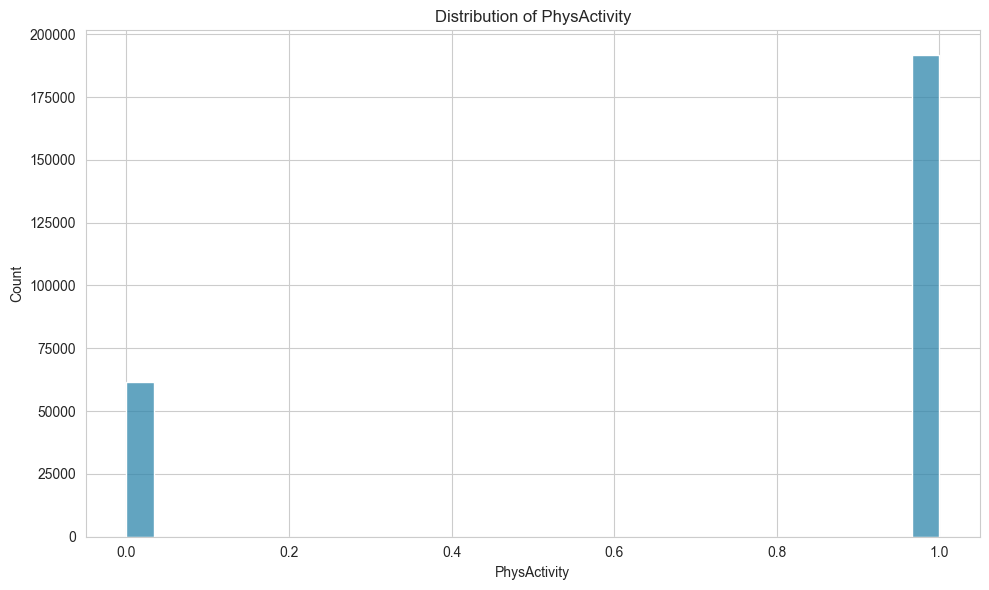

Saved plot for PhysActivity to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_PhysActivity.png


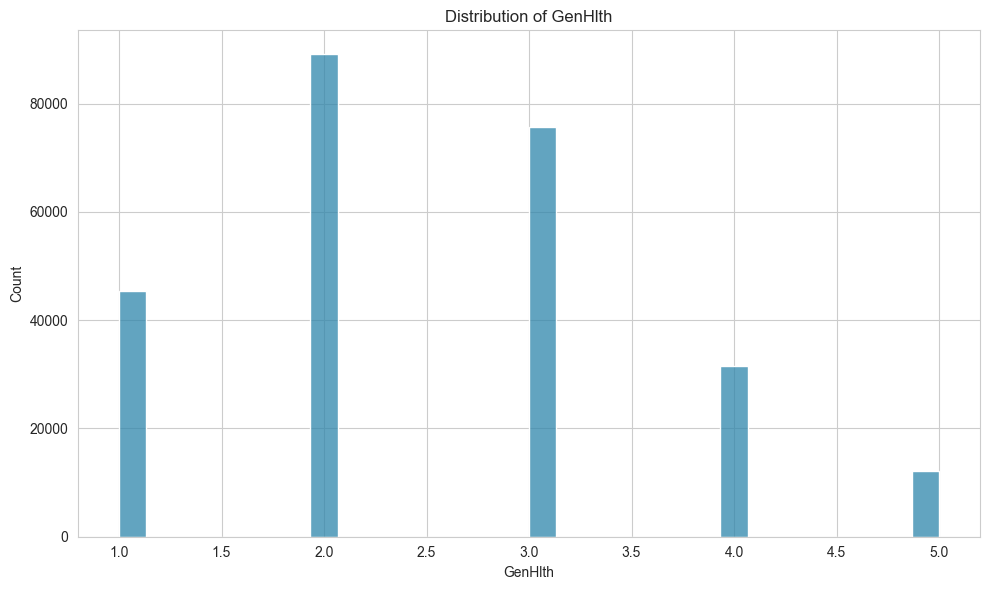

Saved plot for GenHlth to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_GenHlth.png


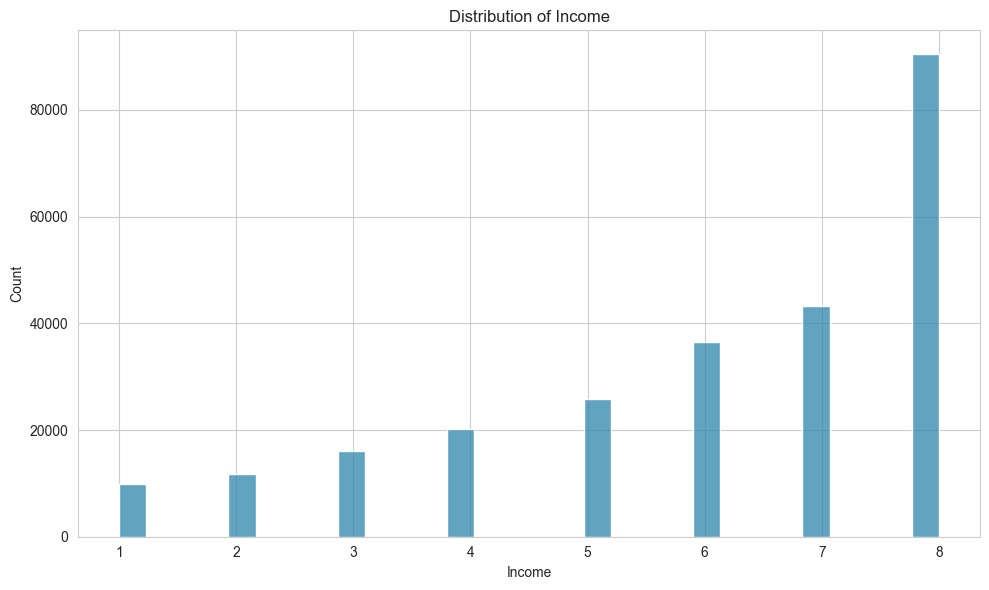

Saved plot for Income to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_Income.png


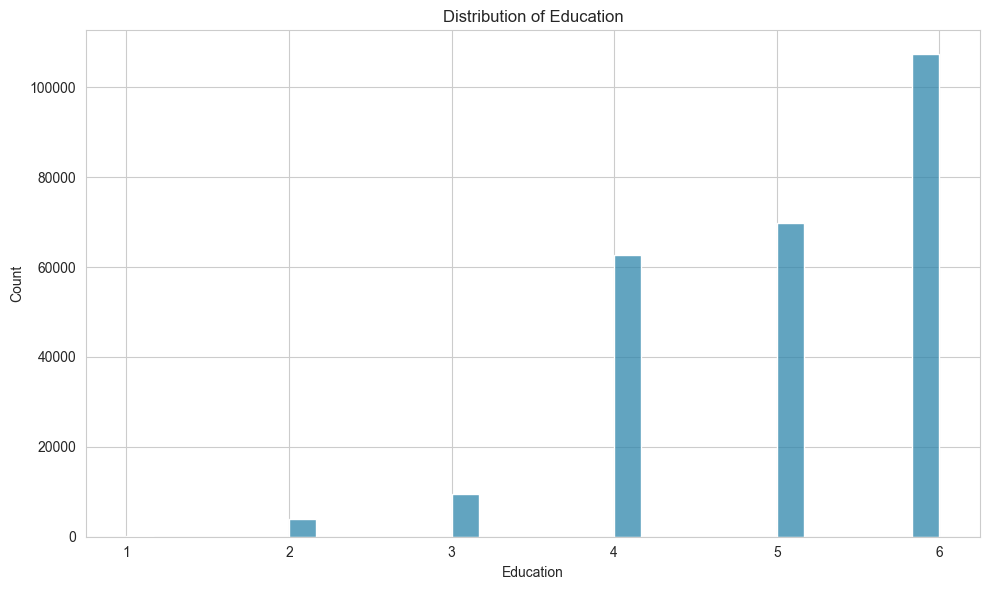

Saved plot for Education to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/distribution_Education.png


In [6]:
key_columns = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity', 'GenHlth', 'Income', 'Education']
available_columns = [col for col in key_columns if col in df.columns]
print('Plotted columns:', available_columns)

for col in available_columns:
    plt.figure()
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(df[col].dropna(), kde=False, bins=30, color='#2E86AB')
        plt.xlabel(col)
        plt.title(f'Distribution of {col}')
    else:
        sns.countplot(x=col, data=df, hue=col, palette='deep', legend=False)
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45, ha='right')
    plot_path = OUTPUT_DIR / f'distribution_{col}.png'
    plt.tight_layout()
    plt.savefig(plot_path)
    plt.show()
    print(f'Saved plot for {col} to {plot_path}')

The selected variables are relevant for diabetes risk modeling and cover both clinical indicators and lifestyle measures.

## Relationship between features and diabetes target

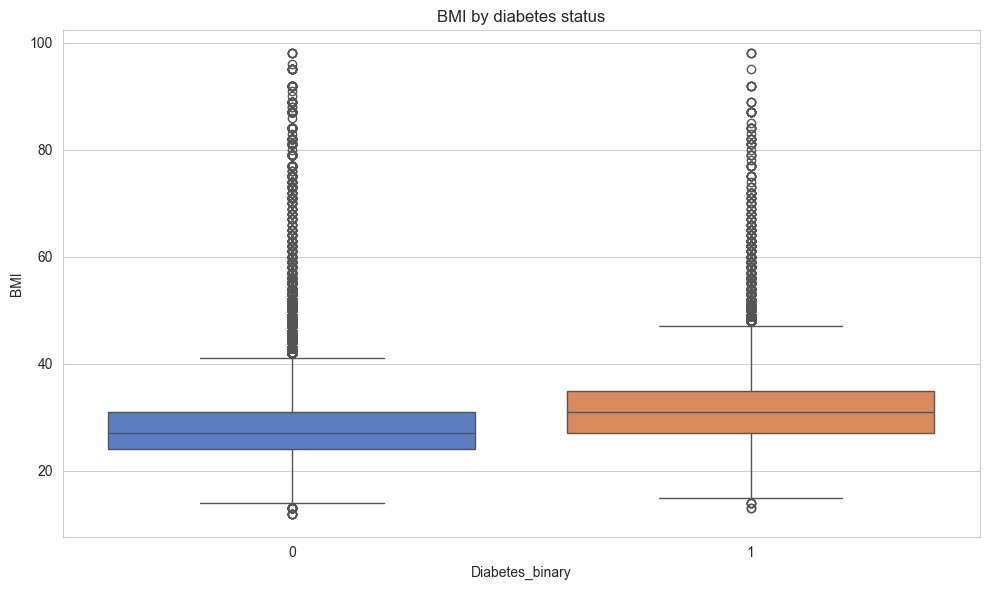

Saved relationship plot for BMI to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/relationship_BMI.png


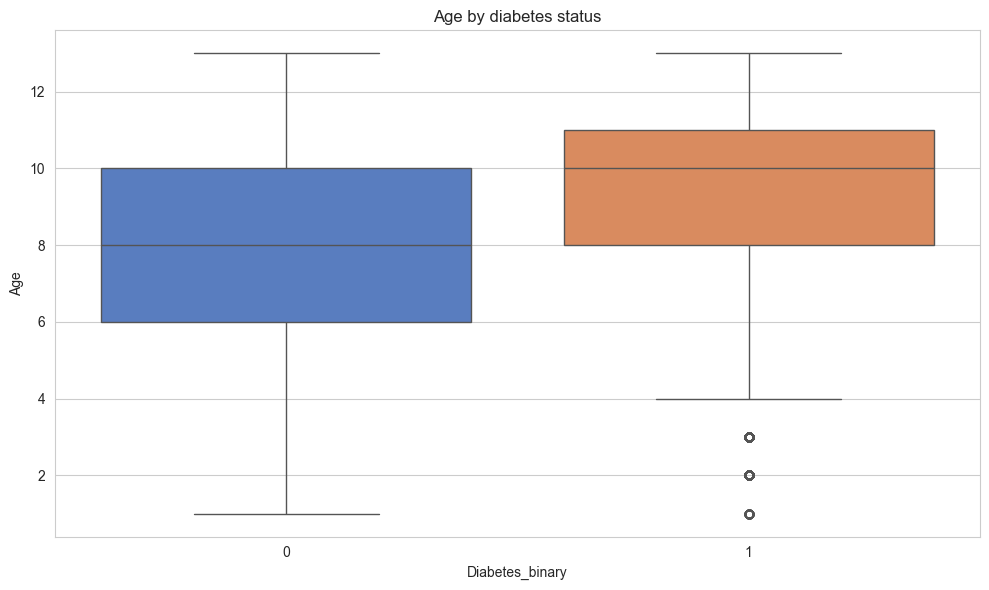

Saved relationship plot for Age to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/relationship_Age.png


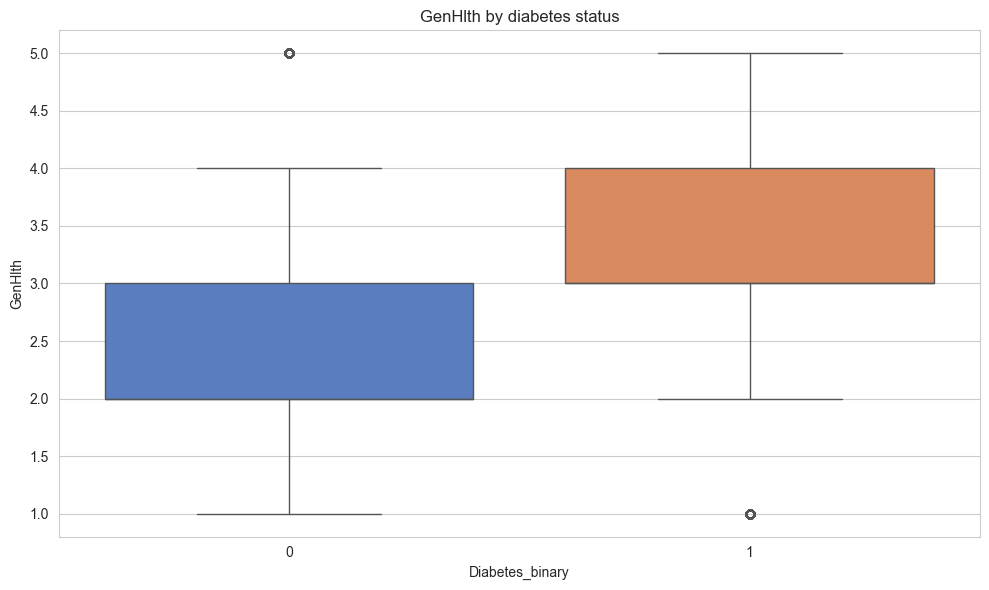

Saved relationship plot for GenHlth to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/relationship_GenHlth.png


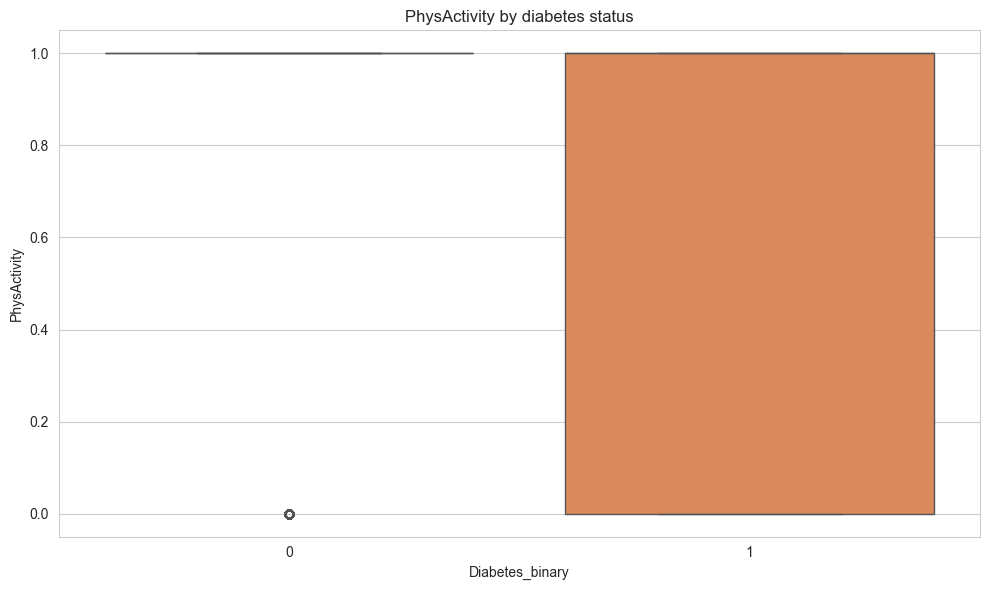

Saved relationship plot for PhysActivity to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/relationship_PhysActivity.png


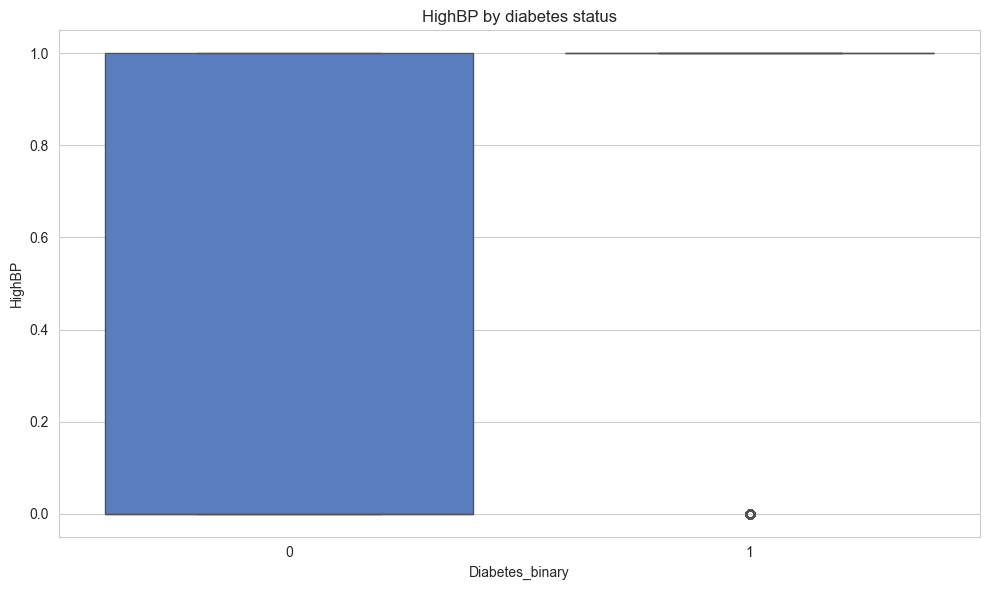

Saved relationship plot for HighBP to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/relationship_HighBP.png


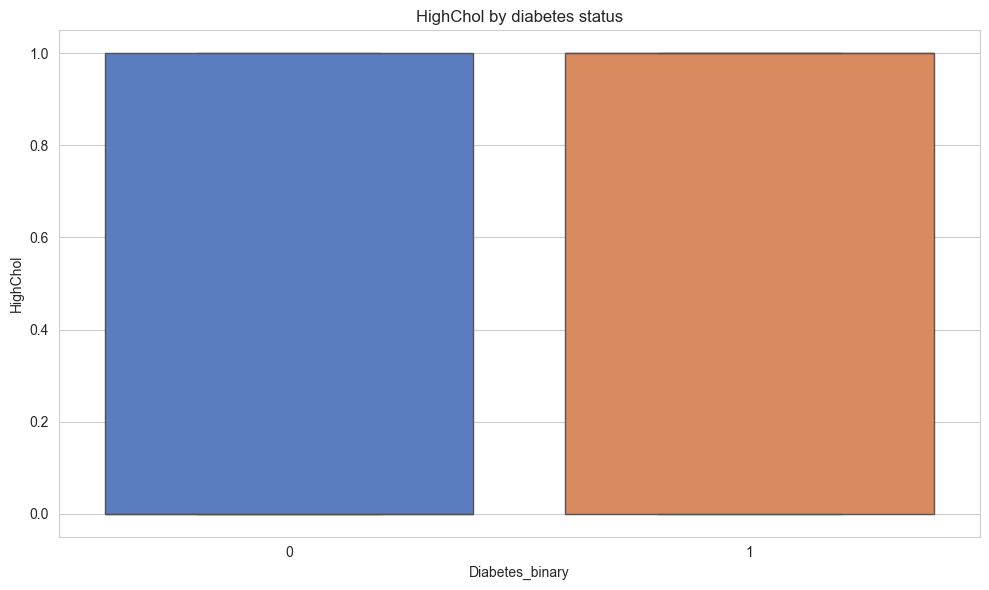

Saved relationship plot for HighChol to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/relationship_HighChol.png


In [7]:
relationship_cols = ['BMI', 'Age', 'GenHlth', 'PhysActivity', 'HighBP', 'HighChol']
relationship_cols = [col for col in relationship_cols if col in df.columns]

for col in relationship_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        plt.figure()
        sns.boxplot(x=y, y=df[col], hue=y, palette='muted', legend=False)
        plt.title(f'{col} by diabetes status')
        plt.xlabel(target_name)
        plt.ylabel(col)
    else:
        plt.figure()
        sns.countplot(x=col, hue=y, data=df, palette='muted')
        plt.title(f'{col} by diabetes status')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel(col)
        plt.ylabel('Count')
    plot_path = OUTPUT_DIR / f'relationship_{col}.png'
    plt.tight_layout()
    plt.savefig(plot_path)
    plt.show()
    print(f'Saved relationship plot for {col} to {plot_path}')

These plots compare the distribution of key variables across diabetes classes, helping to identify features that may be relevant in model training.

## Correlation heatmap

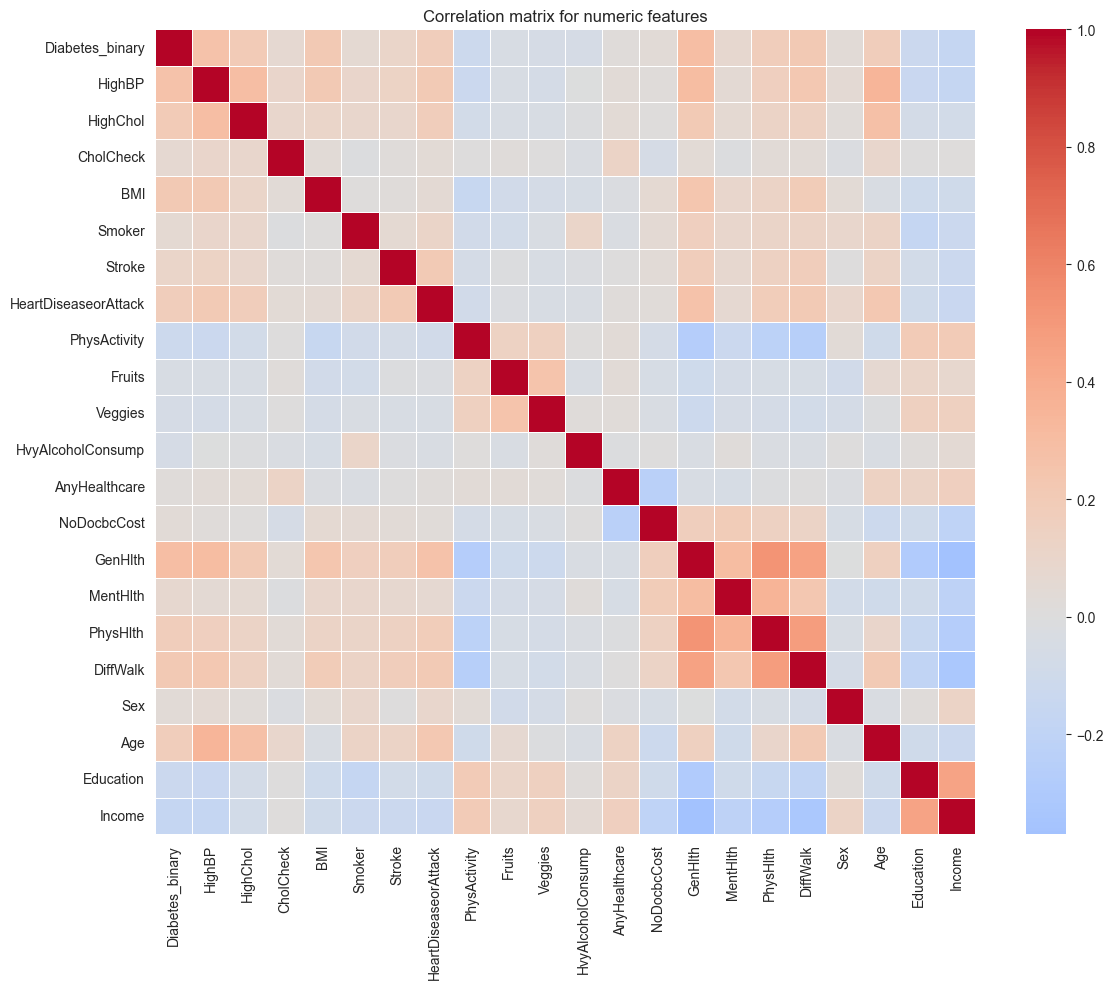

Saved correlation heatmap to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/correlation_heatmap.png


In [8]:
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix for numeric features')
plot_path = OUTPUT_DIR / 'correlation_heatmap.png'
plt.tight_layout()
plt.savefig(plot_path)
plt.show()
print(f'Saved correlation heatmap to {plot_path}')

The correlation heatmap provides a high-level view of linear relationships, which is useful for initial feature selection and data understanding.

## Grouped analysis

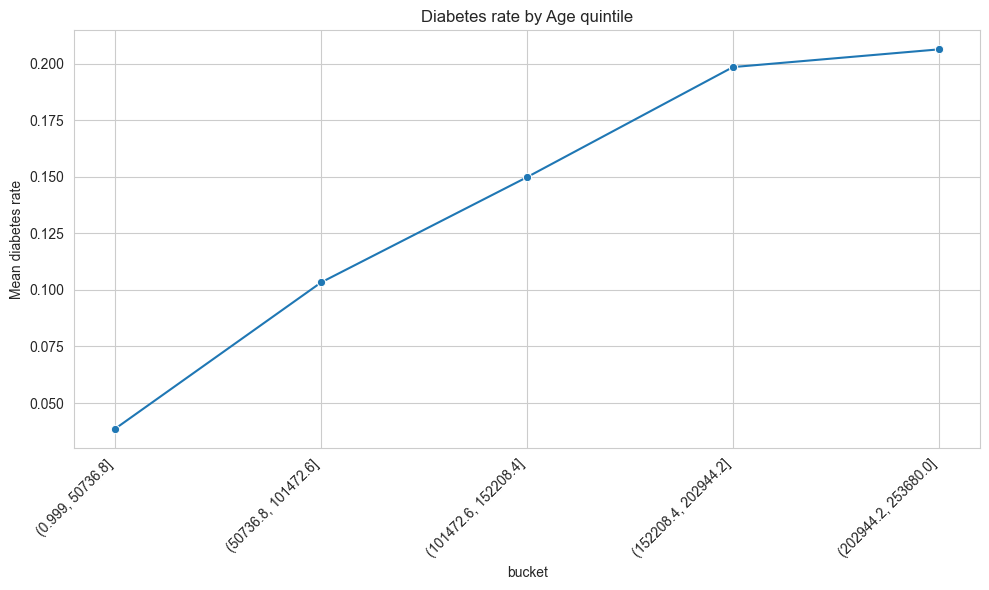

Saved grouped analysis for Age to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/grouped_Age.png


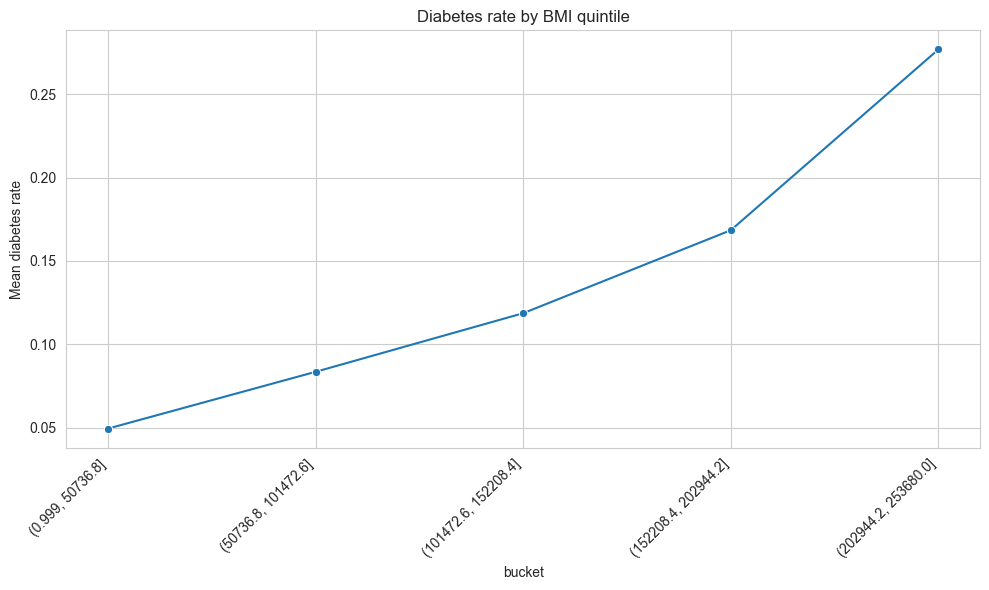

Saved grouped analysis for BMI to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/grouped_BMI.png


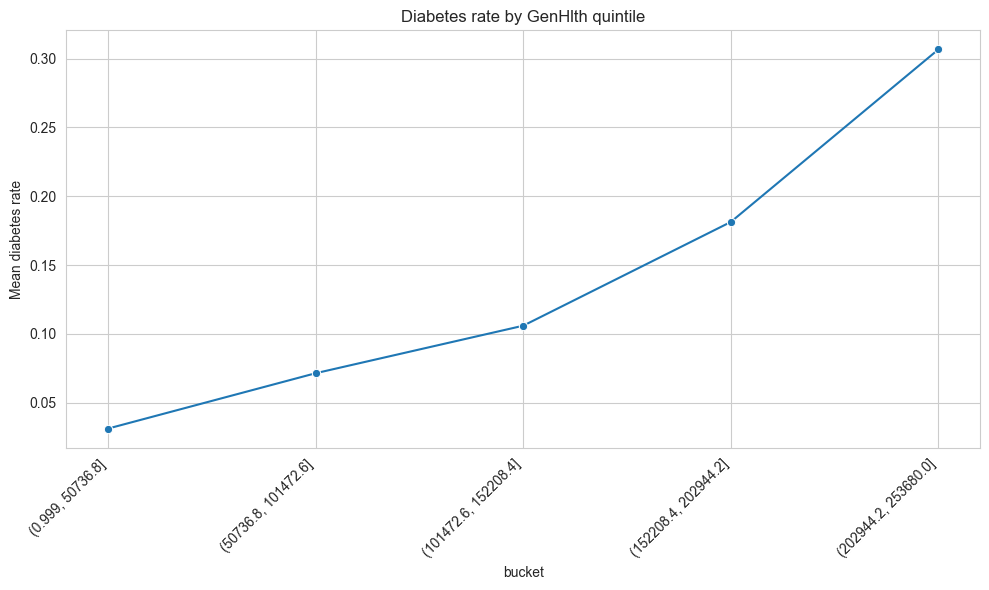

Saved grouped analysis for GenHlth to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/grouped_GenHlth.png


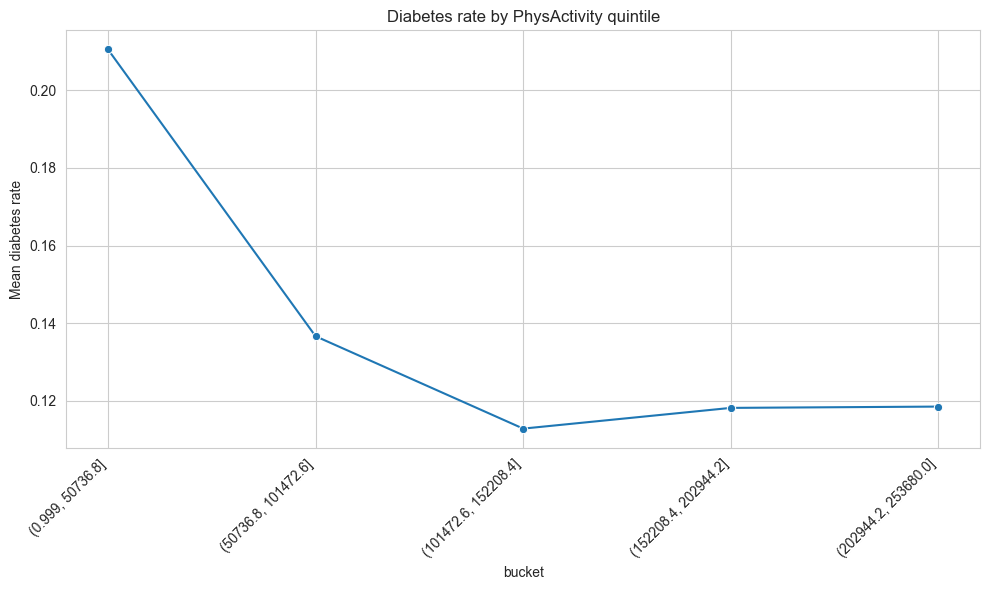

Saved grouped analysis for PhysActivity to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/images/grouped_PhysActivity.png


In [9]:
group_cols = ['Age', 'BMI', 'GenHlth', 'PhysActivity']
group_cols = [col for col in group_cols if col in df.columns]

for col in group_cols:
    analysis_df = df[[col, target_name]].copy()
    analysis_df = analysis_df.rename(columns={target_name: 'target'})
    if pd.api.types.is_numeric_dtype(analysis_df[col]):
        analysis_df['bucket'] = pd.qcut(
            analysis_df[col].rank(method='first'), q=5, duplicates='drop'
        )
        summary = analysis_df.groupby('bucket')['target'].mean().reset_index()
        summary['bucket'] = summary['bucket'].astype(str)  # Interval -> string for seaborn
        plt.figure()
        sns.lineplot(data=summary, x='bucket', y='target', marker='o')
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Diabetes rate by {col} quintile')
        plt.ylabel('Mean diabetes rate')
    else:
        summary = analysis_df.groupby(col)['target'].mean().reset_index()
        plt.figure()
        sns.barplot(data=summary, x=col, y='target', hue=col, palette='muted', legend=False)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Diabetes rate by {col}')
        plt.ylabel('Mean diabetes rate')
    plot_path = OUTPUT_DIR / f'grouped_{col}.png'
    plt.tight_layout()
    plt.savefig(plot_path)
    plt.show()
    print(f'Saved grouped analysis for {col} to {plot_path}')

Grouped analysis offers a structured view of how diabetes risk varies across age, BMI, general health, and physical activity segments.

## Interpretation summary

This EDA documents the dataset and establishes a foundation for modeling. The focus remains on clear data insights and professional presentation rather than medical conclusions.